## Supermarket Sales Analysis

### Project Overview

Aries company operates supermarket branches in Lagos, Abuja and Port Harcourt. 
The company has collected three months of transaction data and wants to understand 
customer behaviour, sales performance, payment preferences and branch performance.

This project analyzes the supermarket transaction data to identify patterns and 
generate actionable insights that can help management improve revenue, customer 
satisfaction and operational efficiency.

### Business Problem
Management needs a clearer picture of which branches and product lines are performing well, how different customer groups are purchasing, and when customers are most active. There is also a need to understand whether customer ratings and purchasing patterns differ across the branches.

This analysis will examine the available transaction data to uncover these patterns and provide insights that can support Aries in making better decisions about sales, customer experience and day-to-day operations.

### Importing Libraries
The following python libraries will be used for data manipulation, analysis and visualization

In [5]:
import pandas as pd
import numpy as np

#Data Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

### Loading the Data
The sales data is provided in three separate CSV files for each branch of Aries supermarket.

In [7]:
lagos = pd.read_csv('Lagos_Branch.csv')
abuja = pd.read_csv('Abuja_Branch.csv')
ph = pd.read_csv('Port_Harcourt_Branch.csv')

### Data undestanding/Inspection

In [9]:
lagos.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Lagos,Member,Female,Health and beauty,26888.4,7,9410.94,197629.74,1/5/2019,13:08,Epay,188218.8,4.761905,9410.94,9.1
1,631-41-3108,A,Lagos,Normal,Male,Home and lifestyle,16678.8,7,5837.58,122589.18,3/3/2019,13:23,Card,116751.6,4.761905,5837.58,7.4
2,123-19-1176,A,Lagos,Member,Male,Health and beauty,20959.2,8,8383.68,176057.28,1/27/2019,20:33,Epay,167673.6,4.761905,8383.68,8.4
3,373-73-7910,A,Lagos,Normal,Male,Sports and travel,31071.6,7,10875.06,228376.26,2/8/2019,10:37,Epay,217501.2,4.761905,10875.06,5.3
4,355-53-5943,A,Lagos,Member,Female,Electronic accessories,24782.4,6,7434.72,156129.12,2/25/2019,14:36,Epay,148694.4,4.761905,7434.72,5.8


In [10]:
abuja.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,692-92-5582,B,Abuja,Member,Female,Food and beverages,19742.4,3,2961.36,62188.56,2/20/2019,13:27,Card,59227.2,4.761905,2961.36,5.9
1,351-62-0822,B,Abuja,Member,Female,Fashion accessories,5212.8,4,1042.56,21893.76,2/6/2019,18:07,Epay,20851.2,4.761905,1042.56,4.5
2,529-56-3974,B,Abuja,Member,Male,Electronic accessories,9183.6,4,1836.72,38571.12,3/9/2019,17:03,Cash,36734.4,4.761905,1836.72,6.8
3,299-46-1805,B,Abuja,Member,Female,Sports and travel,33739.2,6,10121.76,212556.96,1/15/2019,16:19,Cash,202435.2,4.761905,10121.76,4.5
4,319-50-3348,B,Abuja,Normal,Female,Home and lifestyle,14508.0,2,1450.80,30466.80,3/11/2019,15:30,Epay,29016.0,4.761905,1450.80,4.4


In [11]:
ph.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,226-31-3081,C,Port Harcourt,Normal,Female,Electronic accessories,5500.8,5,1375.20,28879.20,3/8/2019,10:29,Cash,27504.0,4.761905,1375.20,9.6
1,699-14-3026,C,Port Harcourt,Normal,Male,Electronic accessories,30740.4,7,10759.14,225941.94,3/25/2019,18:30,Epay,215182.8,4.761905,10759.14,4.1
2,315-22-5665,C,Port Harcourt,Normal,Female,Home and lifestyle,26481.6,10,13240.80,278056.80,2/24/2019,11:38,Epay,264816.0,4.761905,13240.80,8.0
3,300-71-4605,C,Port Harcourt,Member,Male,Electronic accessories,30974.4,5,7743.60,162615.60,2/25/2019,11:24,Epay,154872.0,4.761905,7743.60,4.8
4,183-56-6882,C,Port Harcourt,Member,Female,Food and beverages,35791.2,4,7158.24,150323.04,2/6/2019,10:42,Epay,143164.8,4.761905,7158.24,7.5


In [12]:
print("Lagos:",lagos.shape)
print("Abuja:",abuja.shape)
print("Port Harcourt:",ph.shape)

Lagos: (340, 17)
Abuja: (332, 17)
Port Harcourt: (328, 17)


In [13]:
lagos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               340 non-null    object 
 1   Branch                   340 non-null    object 
 2   City                     340 non-null    object 
 3   Customer type            340 non-null    object 
 4   Gender                   340 non-null    object 
 5   Product line             340 non-null    object 
 6   Unit price               340 non-null    float64
 7   Quantity                 340 non-null    int64  
 8   Tax 5%                   340 non-null    float64
 9   Total                    340 non-null    float64
 10  Date                     340 non-null    object 
 11  Time                     340 non-null    object 
 12  Payment                  340 non-null    object 
 13  cogs                     340 non-null    float64
 14  gross margin percentage  3

In [14]:
abuja.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               332 non-null    object 
 1   Branch                   332 non-null    object 
 2   City                     332 non-null    object 
 3   Customer type            332 non-null    object 
 4   Gender                   332 non-null    object 
 5   Product line             332 non-null    object 
 6   Unit price               332 non-null    float64
 7   Quantity                 332 non-null    int64  
 8   Tax 5%                   332 non-null    float64
 9   Total                    332 non-null    float64
 10  Date                     332 non-null    object 
 11  Time                     332 non-null    object 
 12  Payment                  332 non-null    object 
 13  cogs                     332 non-null    float64
 14  gross margin percentage  3

In [15]:
ph.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               328 non-null    object 
 1   Branch                   328 non-null    object 
 2   City                     328 non-null    object 
 3   Customer type            328 non-null    object 
 4   Gender                   328 non-null    object 
 5   Product line             328 non-null    object 
 6   Unit price               328 non-null    float64
 7   Quantity                 328 non-null    int64  
 8   Tax 5%                   328 non-null    float64
 9   Total                    328 non-null    float64
 10  Date                     328 non-null    object 
 11  Time                     328 non-null    object 
 12  Payment                  328 non-null    object 
 13  cogs                     328 non-null    float64
 14  gross margin percentage  3

### Data Cleaning and Preparation


In [17]:
#Checking for duplicates
print("Lagos:",lagos.duplicated().sum())
print("Abuja:",abuja.duplicated().sum())
print("Port Harcourt:",ph.duplicated().sum())
      

Lagos: 0
Abuja: 0
Port Harcourt: 0


In [18]:
#Combining the datasets into one dataframe
df = pd.concat([lagos, abuja, ph,], ignore_index=True)


In [19]:
df.shape

(1000, 17)

In [20]:
#checking the datatypes of each column
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [21]:
df[['Date', 'Time']].head()

,Date,Time
0,1/5/2019,13:08
1,3/3/2019,13:23
2,1/27/2019,20:33
3,2/8/2019,10:37
4,2/25/2019,14:36


In [22]:
#Changing the date column datatype
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype

dtype('<M8[ns]')

In [23]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,Date,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1.000000e+03,1000.000000,1000.00000
mean,20041.966800,5.510000,5536.572840,116268.029640,2019-02-14 00:05:45.600000,110731.456800,4.761905e+00,5536.572840,6.97270
min,3628.800000,1.000000,183.060000,3844.260000,2019-01-01 00:00:00,3661.200000,4.761905e+00,183.060000,4.00000
25%,11835.000000,3.000000,2132.955000,44792.055000,2019-01-24 00:00:00,42659.100000,4.761905e+00,2132.955000,5.50000
50%,19882.800000,5.000000,4351.680000,91385.280000,2019-02-13 00:00:00,87033.600000,4.761905e+00,4351.680000,7.00000
75%,28056.600000,8.000000,8080.290000,169686.090000,2019-03-08 00:00:00,161605.800000,4.761905e+00,8080.290000,8.50000
max,35985.600000,10.000000,17874.000000,375354.000000,2019-03-30 00:00:00,357480.000000,4.761905e+00,17874.000000,10.00000
std,9538.066205,2.923431,4215.177173,88518.720636,NaN,84303.543463,6.131498e-14,4215.177173,1.71858


In [24]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Lagos,Member,Female,Health and beauty,26888.4,7,9410.94,197629.74,2019-01-05,13:08,Epay,188218.8,4.761905,9410.94,9.1
1,631-41-3108,A,Lagos,Normal,Male,Home and lifestyle,16678.8,7,5837.58,122589.18,2019-03-03,13:23,Card,116751.6,4.761905,5837.58,7.4
2,123-19-1176,A,Lagos,Member,Male,Health and beauty,20959.2,8,8383.68,176057.28,2019-01-27,20:33,Epay,167673.6,4.761905,8383.68,8.4
3,373-73-7910,A,Lagos,Normal,Male,Sports and travel,31071.6,7,10875.06,228376.26,2019-02-08,10:37,Epay,217501.2,4.761905,10875.06,5.3
4,355-53-5943,A,Lagos,Member,Female,Electronic accessories,24782.4,6,7434.72,156129.12,2019-02-25,14:36,Epay,148694.4,4.761905,7434.72,5.8


In [25]:
df.describe(include='object')

,Invoice ID,Branch,City,Customer type,Gender,Product line,Time,Payment
count,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,3,2,2,6,506,3
top,750-67-8428,A,Lagos,Member,Female,Fashion accessories,14:42,Epay
freq,1,340,340,501,501,178,7,345


In [26]:
#Checking for null values
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [27]:
df['Branch'].unique()

array(['A', 'B', 'C'], dtype=object)

In [28]:
df['City'].unique()

array(['Lagos', 'Abuja', 'Port Harcourt'], dtype=object)

In [29]:
print(df['Customer type'].unique())
print(df['Gender'].unique())
print(df['Payment'].unique())

['Member' 'Normal']
['Female' 'Male']
['Epay' 'Card' 'Cash']


### Adding Necessary Columns

In [31]:
#Creating Month column from date provided
df['Month'] = df['Date'].dt.month_name()
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month
0,750-67-8428,A,Lagos,Member,Female,Health and beauty,26888.4,7,9410.94,197629.74,2019-01-05,13:08,Epay,188218.8,4.761905,9410.94,9.1,January
1,631-41-3108,A,Lagos,Normal,Male,Home and lifestyle,16678.8,7,5837.58,122589.18,2019-03-03,13:23,Card,116751.6,4.761905,5837.58,7.4,March
2,123-19-1176,A,Lagos,Member,Male,Health and beauty,20959.2,8,8383.68,176057.28,2019-01-27,20:33,Epay,167673.6,4.761905,8383.68,8.4,January
3,373-73-7910,A,Lagos,Normal,Male,Sports and travel,31071.6,7,10875.06,228376.26,2019-02-08,10:37,Epay,217501.2,4.761905,10875.06,5.3,February
4,355-53-5943,A,Lagos,Member,Female,Electronic accessories,24782.4,6,7434.72,156129.12,2019-02-25,14:36,Epay,148694.4,4.761905,7434.72,5.8,February


In [32]:
#Creating Day of the week column
df['Day of Week']= df['Date'].dt.day_name()
df[['Date','Month','Day of Week']].head()

,Date,Month,Day of Week
0,2019-01-05,January,Saturday
1,2019-03-03,March,Sunday
2,2019-01-27,January,Sunday
3,2019-02-08,February,Friday
4,2019-02-25,February,Monday


In [33]:
#Creating Hour column from Time provided
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
df[['Time','Hour']].head()

,Time,Hour
0,13:08,13
1,13:23,13
2,20:33,20
3,10:37,10
4,14:36,14


In [34]:
#Checking for duplicates
df.duplicated().sum()

0

In [35]:
#Checking column datatypes
df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
Month                              object
Day of Week                        object
Hour                                int32
dtype: object

In [36]:
#Checking data date range
print('Start date:', df['Date'].min())
print('End date:', df['Date'].max())

Start date: 2019-01-01 00:00:00
End date: 2019-03-30 00:00:00


In [37]:
df['Month'].value_counts()

Month
January     352
March       345
February    303
Name: count, dtype: int64

`Cleaning Decisions` The following data preparation steps were carried out before analysis:
- Converted the Date column to datetime format.
- Created a Month column from the transaction date.
- Created a Day of Week column from the transaction date.
- Created an Hour column from the transaction time to support time-based analysis.
- Checked the dataset for missing values. No missing values were found.
- Checked for duplicate records. No duplicates were found.
- The original transaction data was retained, and no rows were removed during cleaning.
- Created a Day Type column to classify transactions as either Weekday or Weekend for additional analysis.
- The three branch datasets were combined into a single DataFrame for analysis.

### Key Performance Indicators

This section provides an overview of key business metrics across the three-month period.

In [40]:
total_orders = df['Invoice ID'].nunique()
total_sales = df['Total'].sum()
total_quantity = df['Quantity'].sum()
average_order_value = df['Total'].mean()
average_rating = df['Rating'].mean()
total_gross_income = df['gross income'].sum()

print(f"Total Orders: {total_orders:,}")
print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Average Customer Rating: {average_rating:.2f}")
print(f"Total Gross Income: {total_gross_income:,.2f}")

Total Orders: 1,000
Total Sales: 116,268,029.64
Total Quantity Sold: 5,510
Average Order Value: 116,268.03
Average Customer Rating: 6.97
Total Gross Income: 5,536,572.84


### Exploratory Data Analysis

In [42]:
# Total sales generated over the 3 months period
df['Total'].sum()

116268029.64

In [43]:
#Which branch generates the highest total sales?
df.groupby('City')['Total'].sum()

City
Abuja            38231161.92
Lagos            38232133.38
Port Harcourt    39804734.34
Name: Total, dtype: float64

In [44]:
#Which branch generates the highest gross income?
df.groupby('City')['gross income'].sum()

City
Abuja            1820531.52
Lagos            1820577.78
Port Harcourt    1895463.54
Name: gross income, dtype: float64

In [45]:
#How does sales performance change across the three months?
df.groupby('Month')['Total'].sum()

Month
February    34998974.64
January     41865072.48
March       39403982.52
Name: Total, dtype: float64

In [46]:
#Which products line generates the highest sales?
df.groupby('Product line')['Total'].sum().sort_values(ascending=False)

Product line
Food and beverages        20212143.84
Sports and travel         19844217.54
Electronic accessories    19561511.34
Fashion accessories       19550122.20
Home and lifestyle        19390288.68
Health and beauty         17709746.04
Name: Total, dtype: float64

### Product Line Performance by Branch

To determine whether product performance varies across branches, sales were compared by product line for each city.

In [48]:
branch_product_sales = (df.groupby(['City', 'Product line'])['Total'].sum().reset_index())

branch_product_sales

,City,Product line,Total
0,Abuja,Electronic accessories,6138519.66
1,Abuja,Fashion accessories,5908793.94
2,Abuja,Food and beverages,5477359.86
3,Abuja,Health and beauty,7193037.60
4,Abuja,Home and lifestyle,6317699.22
5,Abuja,Sports and travel,7195751.64
6,Lagos,Electronic accessories,6594160.86
7,Lagos,Fashion accessories,5879703.06
8,Lagos,Food and beverages,6178716.18
9,Lagos,Health and beauty,4535191.08


In [49]:
branch_product_sales.loc[branch_product_sales.groupby('City')['Total'].idxmax()]

,City,Product line,Total
5,Abuja,Sports and travel,7195751.64
10,Lagos,Home and lifestyle,8070190.38
14,Port Harcourt,Food and beverages,8556067.80


`Observation`
Product performance varies across the three branches. Home and Lifestyle recorded the highest sales in Lagos, Sports and Travel recorded the highest sales in Abuja, while Food and Beverages recorded the highest sales in Port Harcourt.

This indicates that the strongest-performing product line is not the same across all branches, suggesting that product performance should be considered at the branch level.

In [51]:
#Which products line have the highest quantity sold?
df.groupby('Product line')['Quantity'].sum().sort_values(ascending=False)

Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64

In [52]:
# Comparing total sales by customer type
df.groupby('Customer type')['Total'].sum()

Customer type
Member    59120439.84
Normal    57147589.80
Name: Total, dtype: float64

In [53]:
# Sales by Gender
df.groupby('Gender')['Total'].sum()

Gender
Female    60437853.00
Male      55830176.64
Name: Total, dtype: float64

In [54]:
#The most used method of Payment
df['Payment'].value_counts()

Payment
Epay    345
Cash    344
Card    311
Name: count, dtype: int64

In [55]:
#The most used method of Payment across Branches
df.groupby(['City','Payment']).size()

City           Payment
Abuja          Card       109
               Cash       110
               Epay       113
Lagos          Card       104
               Cash       110
               Epay       126
Port Harcourt  Card        98
               Cash       124
               Epay       106
dtype: int64

In [56]:
# Comparing average customer ratings across branches
df.groupby('City')['Rating'].mean()

City
Abuja            6.818072
Lagos            7.027059
Port Harcourt    7.072866
Name: Rating, dtype: float64

In [57]:
# What are the busiest shopping hours overall?
df['Hour'].value_counts().sort_index()

Hour
10    101
11     90
12     89
13    103
14     83
15    102
16     77
17     74
18     93
19    113
20     75
Name: count, dtype: int64

In [58]:
#Busiest shopping hours across branches
df.groupby(['City', 'Hour']).size().sort_values(ascending=False)

City           Hour
Abuja          19      50
               13      38
Lagos          10      38
               15      37
Port Harcourt  10      37
               19      36
Lagos          11      35
Abuja          18      35
Port Harcourt  13      34
Lagos          18      33
Abuja          11      33
Lagos          12      33
Port Harcourt  15      33
Lagos          16      32
Abuja          15      32
Lagos          13      31
Port Harcourt  12      31
Abuja          14      30
Port Harcourt  16      28
               14      28
               17      27
               20      27
Lagos          19      27
               17      27
Abuja          20      26
               10      26
Lagos          14      25
Port Harcourt  18      25
Abuja          12      25
Lagos          20      22
Port Harcourt  11      22
Abuja          17      20
               16      17
dtype: int64

*Interpretation:* Peak transaction hours varied across the three branches. Abuja recorded its highest transaction activity at 7 PM, while Lagos and Port Harcourt recorded their highest activity at 10 AM. This suggests that customer traffic patterns differ by branch and that staffing and operational planning could be adjusted to reflect each branch's busiest period.

In [60]:
# Relationship between customer ratings, sales and gross income 
df[['Rating', 'Total', 'gross income']].corr()

,Rating,Total,gross income
Rating,1.000000,-0.036442,-0.036442
Total,-0.036442,1.000000,1.000000
gross income,-0.036442,1.000000,1.000000


In [61]:
# Sales by customer segment
df.groupby(['City', 'Gender', 'Customer type'])['Total'].sum().sort_values(ascending=False)

City           Gender  Customer type
Port Harcourt  Female  Member           12475239.84
                       Normal            9731526.84
Lagos          Male    Member            9717986.88
Abuja          Male    Member            9667531.44
               Female  Member            9666155.52
Port Harcourt  Male    Normal            9595945.80
Lagos          Female  Member            9591504.30
                       Normal            9585395.82
Abuja          Male    Normal            9509444.28
               Female  Normal            9388030.68
Lagos          Male    Normal            9337246.38
Port Harcourt  Male    Member            8002021.86
Name: Total, dtype: float64

*Interpretation:* Port Harcourt Female Members generated the highest sales among all customer segments at approximately 12.48 million, while Port Harcourt Male Members generated the lowest at approximately 8.00 million. Female Members generally recorded strong sales across the three cities, while Male Members showed greater variation between branches. This suggests that customer segment performance differs by both gender and city.

In [63]:
# Comparing quantity sold and revenue by product line
df.groupby('Product line')[['Quantity', 'Total']].sum().sort_values('Total', ascending=False)

,Quantity,Total
Product line,,
Food and beverages,952,20212143.84
Sports and travel,920,19844217.54
Electronic accessories,971,19561511.34
Fashion accessories,902,19550122.20
Home and lifestyle,911,19390288.68
Health and beauty,854,17709746.04


*Interpretation:* Food and beverages generated the highest total sales at approximately 20.2 million, despite not having the highest quantity sold. Electronic accessories had the highest quantity sold at 971 units but generated approximately 19.6 million in sales. This shows that higher sales volume does not necessarily result in the highest revenue, as the value of individual transactions also contributes to total sales.

In [65]:
# Comparing sales between weekdays and weekends
df['Day Type'] = df['Day of Week'].isin(['Saturday', 'Sunday']).map({True: 'Weekend', False: 'Weekday'})
df.groupby('Day Type')['Total'].sum()

Day Type
Weekday    80059696.92
Weekend    36208332.72
Name: Total, dtype: float64

*Interpretation:* Weekday transactions generated higher total sales than weekend transactions, with approximately 80.1 million in weekday sales compared with 36.2 million in weekend sales. However, this difference should be interpreted with caution because the dataset contains more weekdays than weekend days during the three-month period.

In [67]:
df['Day Type'].value_counts()

Day Type
Weekday    703
Weekend    297
Name: count, dtype: int64

`Observation`

Weekdays recorded more transactions and higher total sales than weekends. This suggests that sales activity was more concentrated during weekdays in the period analyzed.

In [70]:
# Comparing average quantity purchased by customer type
df.groupby('Customer type')['Quantity'].mean()

Customer type
Member    5.558882
Normal    5.460922
Name: Quantity, dtype: float64

`Observation` Member customers purchased slightly more items per transaction on average than Normal customers, although the difference was relatively small.

In [72]:
# Relationship between quantity purchased and total sales
df[['Quantity', 'Total']].corr()

,Quantity,Total
Quantity,1.00000,0.70551
Total,0.70551,1.00000


*Interpretation:* The correlation coefficient of approximately 0.71 indicates a strong positive linear relationship between quantity sold and total sales. This suggests that transactions involving larger quantities generally tend to generate higher sales. However, correlation does not imply that higher quantity alone causes higher sales.

In [74]:
df[['cogs','Tax 5%','gross income','Total','gross margin percentage']].head()

,cogs,Tax 5%,gross income,Total,gross margin percentage
0,188218.8,9410.94,9410.94,197629.74,4.761905
1,116751.6,5837.58,5837.58,122589.18,4.761905
2,167673.6,8383.68,8383.68,176057.28,4.761905
3,217501.2,10875.06,10875.06,228376.26,4.761905
4,148694.4,7434.72,7434.72,156129.12,4.761905


In [75]:
# Total sales and tax collected over the 3 month
df[['Total', 'Tax 5%']].sum()

Total     1.162680e+08
Tax 5%    5.536573e+06
dtype: float64

## Visualizations

In [77]:
# Functions to generate plots
def create_bar_plot(data, title, xlabel, ylabel):
    data.plot(kind='bar')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    sb.despine()
    plt.tight_layout()
    plt.savefig(f'Plots/{title}.png')
    plt.show()


def create_line_plot(data, title, xlabel, ylabel):
    data.plot(kind='line', marker='o')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    sb.despine()
    plt.tight_layout()
    plt.savefig(f'Plots/{title}.png')
    plt.show()


def create_pie_plot(data, title):
    plt.figure(figsize=(7, 7))
    data.plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title(title)
    plt.ylabel('')
    sb.despine()
    plt.tight_layout()
    plt.savefig(f'Plots/{title}.png')
    plt.show()


def create_scatter_plot(data, x, y, title, xlabel, ylabel):
    plt.figure(figsize=(8, 5))
    sb.scatterplot(data=data, x=x, y=y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    sb.despine()
    plt.tight_layout()
    plt.savefig(f'Plots/{title}.png')
    plt.show()

### Total Sale by City
This visualization compares total sales generated by each city.


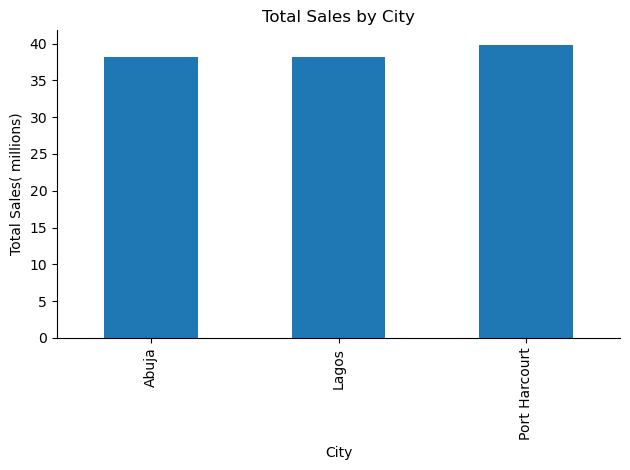

In [79]:
sales_by_city = df.groupby('City')['Total'].sum()/1_000_000

create_bar_plot(sales_by_city, 'Total Sales by City','City','Total Sales( millions)')

*Interpretation:* Port Harcourt generated the highest total sales at approximately 39.8 million, while Lagos and Abuja generated approximately 38.2 million each. The difference between the three cities is relatively small, indicating fairly similar sales performance across the branches.

### Gross Income by City

This visualisation compares the gross income generated by each city.

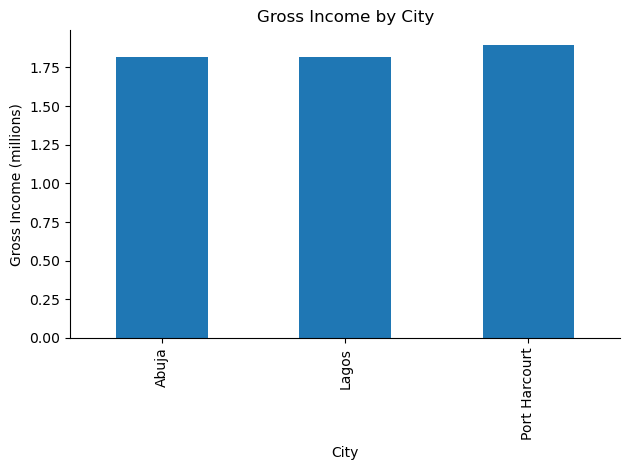

In [82]:
gross_income_by_city = df.groupby('City')['gross income'].sum() / 1_000_000

create_bar_plot(gross_income_by_city,'Gross Income by City','City','Gross Income (millions)')

*Interpretation:* Port Harcourt generated the highest gross income at approximately 1.90 million, followed by Lagos at approximately 1.82 million and Abuja at approximately 1.82 million. The differences between the cities are relatively small.

### Monthly Sales Trend

This visualisation shows how total sales changed across the three months.

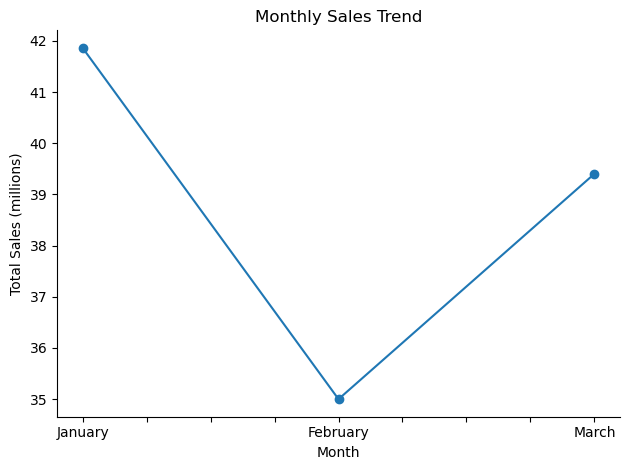

In [85]:
monthly_sales = df.groupby('Month')['Total'].sum() / 1_000_000

monthly_sales = monthly_sales.reindex(['January', 'February', 'March'])

create_line_plot(monthly_sales,'Monthly Sales Trend','Month','Total Sales (millions)')

*Interpretation:* Sales were highest in January at approximately 41.9 million, then declined to approximately 35.0 million in February. Sales recovered in March to approximately 39.4 million, but remained below the January level.

### Total Sales by Product Line
This visualisation compares the total sales generated by each product line

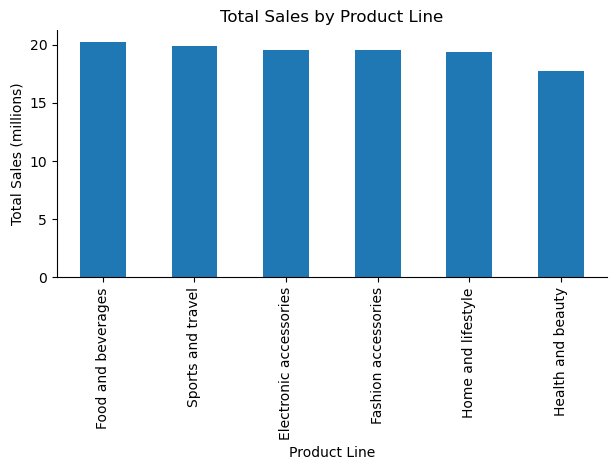

In [88]:
sales_by_product = df.groupby('Product line')['Total'].sum().sort_values(ascending=False)/1_000_000
create_bar_plot(sales_by_product, 'Total Sales by Product Line','Product Line','Total Sales (millions)')

*Interpretation:* Food and beverages generated the highest total sales at approximately 20.2 million, followed by sports and travel at approximately 19.8 million. Health and beauty generated the lowest sales at approximately 17.7 million. Overall, sales across the product lines were relatively close, with food and beverages performing slightly better than the other categories.

#### Total Sales by Customer Type and Gender
This visualization compares total sales across customer types and gender

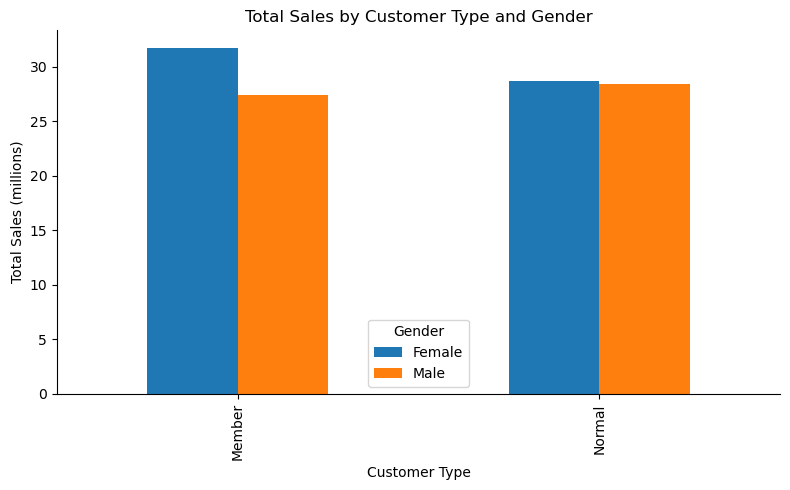

In [91]:
sales_by_customer_gender = df.groupby(['Customer type', 'Gender'])['Total'].sum().unstack()/1_000_000

sales_by_customer_gender.plot(kind='bar', figsize=(8, 5))

plt.title('Total Sales by Customer Type and Gender')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales (millions)')
plt.legend(title='Gender')
sb.despine()
plt.tight_layout()
plt.savefig('Plots/Total Sales by Customer Type and Gender.png')
plt.show()

*Interpretation:* Female Members generated the highest sales among the four customer type and gender segments, followed by Male Members. Sales from Female and Male Normal customers were relatively similar. Overall, Member customers generated slightly higher total sales than Normal customers.

#### Payment Methods by City
This visualization compares the number of transactions made through each payment method across the cities.

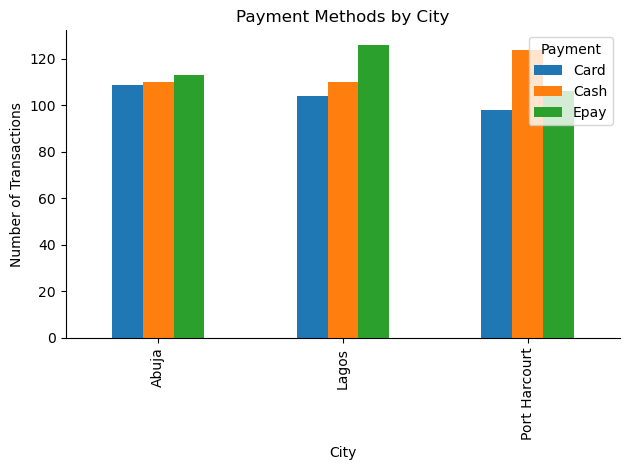

In [94]:
payment_by_city = pd.crosstab(df['City'], df['Payment'])

create_bar_plot(payment_by_city,'Payment Methods by City','City','Number of Transactions')

*Interpretation:* Epay was the most frequently used payment method in Abuja and Lagos, while Cash was the most frequently used method in Port Harcourt. Card payments had the lowest transaction count across all three cities.

#### Average Customer Rating by city
This visualization compares the average customerrating across the three cities.

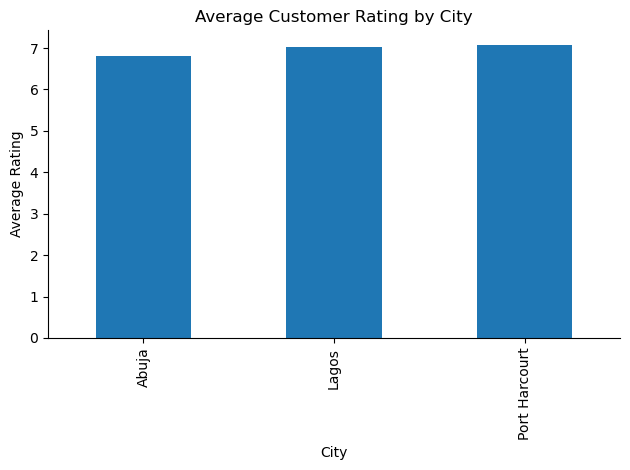

In [97]:
avg_rating_by_city = df.groupby('City')['Rating'].mean()

create_bar_plot(avg_rating_by_city,'Average Customer Rating by City','City','Average Rating')

*Interpretation:* Port Harcourt had the highest average customer rating at approximately 7.07, followed by Lagos at approximately 7.03 and Abuja at approximately 6.82. The differences are relatively small, suggesting that average customer ratings were fairly similar across the three cities.

#### Transactions by Hour
This visualization shows the number of transactions recorded at each hour of the day.

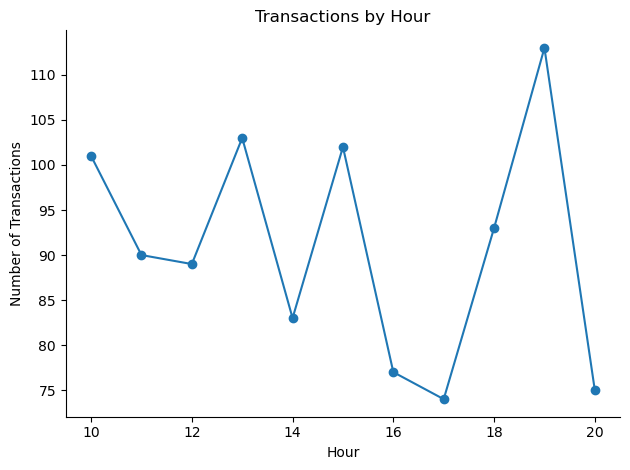

In [100]:
transactions_by_hour = df['Hour'].value_counts().sort_index()

create_line_plot(transactions_by_hour,'Transactions by Hour','Hour','Number of Transactions')

*Interpretation:* Transaction activity varied throughout the day, with the highest number of transactions recorded at 7 PM (113 transactions). Other relatively busy hours included 1 PM, 3 PM, and 10 AM. The lowest transaction count occurred at 5 PM, with 72 transactions.

#### Customer Rating vs Total Sales

This visualisation examines the relationship between customer ratings and transaction sales.

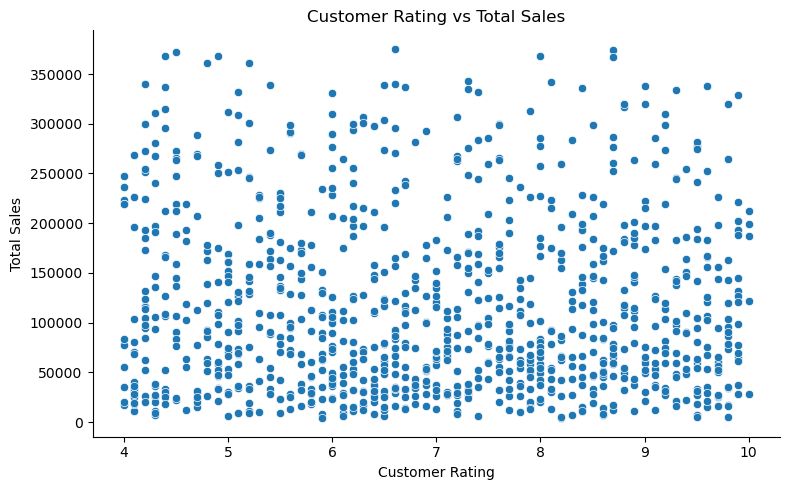

In [103]:
rating_vs_sales = df[['Rating', 'Total']]

create_scatter_plot(rating_vs_sales,'Rating','Total','Customer Rating vs Total Sales','Customer Rating','Total Sales')

*Interpretation:* The scatter plot shows no clear linear relationship between customer rating and total sales. This is consistent with the correlation coefficient of approximately -0.04, indicating a very weak negative linear relationship. Therefore, higher customer ratings were not strongly associated with higher transaction sales in this dataset.

## Key Findings

- Port Harcourt recorded the highest total sales, generating approximately 39.8 million across the three-month period.

- Sales performance varied across the three months, with January recording the highest sales at approximately 41.9 million and February recording the lowest at approximately 35.0 million.

- Food and beverages was the highest-selling product line, generating approximately 20.2 million, while health and beauty recorded the lowest sales at approximately 17.7 million.

- Member customers generated slightly more total sales than Normal customers, with Member sales of approximately 59.1 million compared with approximately 57.1 million for Normal customers.
- Payment preferences differed by city. Epay was the most frequently used payment method in Abuja and Lagos, while Cash was most frequently used in Port Harcourt.
- Customer ratings were relatively similar across the three cities, with Port Harcourt having the highest average rating at approximately 7.07 and Abuja the lowest at approximately 6.82.

- Customer activity varied by hour, with 7 PM recording the highest number of transactions at 113.

- Quantity sold had a strong positive relationship with total sales, with a correlation of approximately 0.71, indicating that transactions with higher quantities generally tended to generate higher sales.

## Business Recommendations

Based on the findings from the analysis, the following actions are recommended for Aries:

- Leverage high-performing product lines to increase sales.
Food and beverages generated the highest total sales at approximately ₦20.2 million. Aries should maintain strong availability of these products and consider targeted promotions or product bundles to encourage additional purchases and build on the category’s existing sales performance.
- Strengthen sales strategies in Abuja and Lagos.
   Port Harcourt recorded the highest total sales, while Abuja and Lagos recorded slightly lower sales. Management should review product demand, customer segments and purchasing patterns in these branches to identify opportunities for increasing sales.
- Strengthen Member customer engagement.
   Member customers generated slightly higher total sales and purchased slightly more items per transaction than Normal customers. Aries could introduce targeted member promotions, loyalty incentives and relevant product offers to encourage continued engagement.

- Review the performance of the Health and Beauty product line.
   Health and beauty generated the lowest total sales among the product lines. Aries should review its product assortment, pricing and promotional activities in this category to identify ways to improve its performance.

- Maintain convenient payment options across branches.
   Payment preferences differed by city, with Epay most frequently used in Abuja and Lagos and Cash most frequently used in Port Harcourt. Aries should maintain reliable access to all major payment methods while ensuring that the most-used options at each branch remain convenient for customers.

### Additional Data to Collect

To support deeper analysis and better decision-making, Aries should consider collecting:

- A unique customer ID to track individual purchasing behaviour, repeat purchases and customer retention.
- Product-level information such as product name, unit cost and profit margin to better evaluate product profitability.
- Customer feedback or satisfaction comments to understand the factors influencing customer ratings.
- Promotion and discount data to measure the effectiveness of marketing campaigns.
- Inventory data to identify stock availability and potential stock-out issues during high-demand periods.

### Limitations
- The dataset does not contain a unique customer identifier, so the number of individual customers and customer retention cannot be determined.
- The dataset covers only three months, which limits the ability to identify longer-term trends or seasonal patterns.

## Conclusion

This analysis provided an overview of sales performance, customer behaviour, product performance and purchasing patterns across Aries' three branches. Port Harcourt recorded the highest total sales, while Food and Beverages was the highest-selling product line. Member customers also generated slightly higher sales than Normal customers, and payment preferences varied across branches.

The analysis also identified differences in customer activity across time and branches, as well as a strong positive relationship between quantity sold and total sales. These findings provide Aries with useful information for improving sales strategies, customer engagement and product performance.